<a href="https://colab.research.google.com/github/Quang365/mri-recognition/blob/main/notebooks/UNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

DATA_ROOT = Path(
    "../../keras_png_slices_data/keras_png_slices_data"
).resolve()

TRAIN_IMAGE_DIR = DATA_ROOT / "keras_png_slices_train"
TRAIN_MASK_DIR = DATA_ROOT / "keras_png_slices_seg_train"

VAL_IMAGE_DIR = DATA_ROOT / "keras_png_slices_validate"
VAL_MASK_DIR = DATA_ROOT / "keras_png_slices_seg_validate"

TEST_IMAGE_DIR = DATA_ROOT / "keras_png_slices_test"
TEST_MASK_DIR = DATA_ROOT / "keras_png_slices_seg_test"

print("Dataset root:", DATA_ROOT)
print("Train images:", TRAIN_IMAGE_DIR.exists())
print("Train masks:", TRAIN_MASK_DIR.exists())

Device: cpu
Dataset root: D:\uq\comp3710\Demo2\keras_png_slices_data\keras_png_slices_data
Train images: True
Train masks: True


In [16]:
train_images = sorted(TRAIN_IMAGE_DIR.glob("*.png"))
train_masks = sorted(TRAIN_MASK_DIR.glob("*.png"))

val_images = sorted(VAL_IMAGE_DIR.glob("*.png"))
val_masks = sorted(VAL_MASK_DIR.glob("*.png"))

test_images = sorted(TEST_IMAGE_DIR.glob("*.png"))
test_masks = sorted(TEST_MASK_DIR.glob("*.png"))

print("Train:", len(train_images), len(train_masks))
print("Validation:", len(val_images), len(val_masks))
print("Test:", len(test_images), len(test_masks))

print("\nFirst image:", train_images[0].name)
print("First mask :", train_masks[0].name)

unique_values = set()

for mask_path in train_masks:
    mask = np.array(Image.open(mask_path))
    unique_values.update(np.unique(mask).tolist())

print("\nUnique mask values:", sorted(unique_values))

Train: 9664 9664
Validation: 1120 1120
Test: 544 544

First image: case_001_slice_0.nii.png
First mask : seg_001_slice_0.nii.png

Unique mask values: [0, 85, 170, 255]


In [17]:
from torch.utils.data import Dataset, DataLoader

NUM_CLASSES = 4

# Original grayscale mask values -> categorical class indices
MASK_TO_CLASS = {
    0: 0,
    85: 1,
    170: 2,
    255: 3
}


class OASISSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_paths = sorted(Path(image_dir).glob("*.png"))
        self.mask_paths = sorted(Path(mask_dir).glob("*.png"))

        if len(self.image_paths) != len(self.mask_paths):
            raise ValueError("Number of images and masks do not match.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # MRI image -> float tensor [1, H, W], range [0, 1]
        image = np.array(
            Image.open(self.image_paths[idx]).convert("L"),
            dtype=np.float32
        ) / 255.0

        # Segmentation mask -> categorical indices 0, 1, 2, 3
        mask_raw = np.array(
            Image.open(self.mask_paths[idx]).convert("L"),
            dtype=np.uint8
        )

        mask = np.zeros_like(mask_raw, dtype=np.int64)

        for pixel_value, class_index in MASK_TO_CLASS.items():
            mask[mask_raw == pixel_value] = class_index

        image = torch.from_numpy(image).unsqueeze(0)
        mask = torch.from_numpy(mask)

        return image, mask

In [18]:
train_dataset = OASISSegmentationDataset(
    TRAIN_IMAGE_DIR,
    TRAIN_MASK_DIR
)

val_dataset = OASISSegmentationDataset(
    VAL_IMAGE_DIR,
    VAL_MASK_DIR
)

test_dataset = OASISSegmentationDataset(
    TEST_IMAGE_DIR,
    TEST_MASK_DIR
)

image, mask = train_dataset[0]

print("Dataset sizes:")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

print("\nImage shape:", image.shape)
print("Image range:", image.min().item(), image.max().item())

print("Mask shape:", mask.shape)
print("Mask dtype:", mask.dtype)
print("Mask classes:", torch.unique(mask).tolist())

Dataset sizes:
Train: 9664
Validation: 1120
Test: 544

Image shape: torch.Size([1, 256, 256])
Image range: 0.0 1.0
Mask shape: torch.Size([256, 256])
Mask dtype: torch.int64
Mask classes: [0, 1, 2, 3]


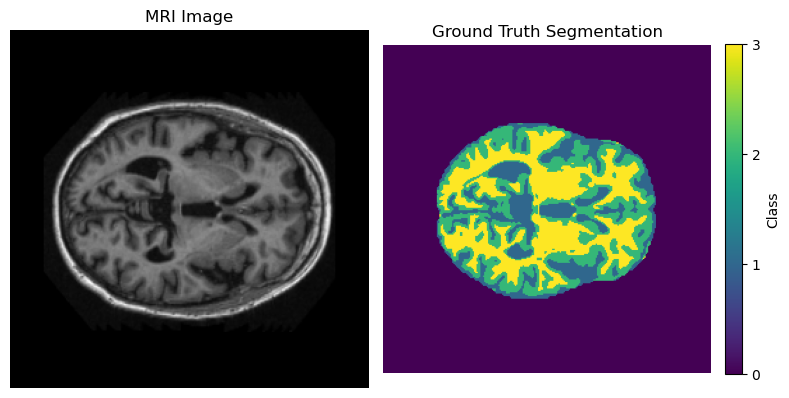

In [19]:
image, mask = train_dataset[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(image.squeeze().numpy(), cmap="gray")
axes[0].set_title("MRI Image")
axes[0].axis("off")

im = axes[1].imshow(
    mask.numpy(),
    cmap="viridis",
    vmin=0,
    vmax=NUM_CLASSES - 1
)
axes[1].set_title("Ground Truth Segmentation")
axes[1].axis("off")

cbar = fig.colorbar(
    im,
    ax=axes[1],
    ticks=range(NUM_CLASSES),
    fraction=0.046,
    pad=0.04
)
cbar.set_label("Class")

plt.tight_layout()
plt.show()

### U-Net Architecture

The encoder extracts increasingly high-level features while reducing
spatial resolution. The decoder restores the original spatial resolution.

Skip connections concatenate encoder features with decoder features,
helping preserve spatial information needed for accurate segmentation.

The final 1×1 convolution produces four logits for every pixel,
corresponding to the four segmentation classes.

In [20]:
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    """Two consecutive 3x3 convolutions with BatchNorm and ReLU."""
    
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=NUM_CLASSES):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.enc4 = DoubleConv(128, 256)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = DoubleConv(256, 512)

        # Decoder
        self.up4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        # One logit channel per segmentation class
        self.output = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder + skip connections
        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.output(d1)

In [21]:
model = UNet().to(device)

dummy_input = torch.randn(2, 1, 256, 256).to(device)

model.eval()
with torch.no_grad():
    logits = model(dummy_input)

print("Input shape :", dummy_input.shape)
print("Output shape:", logits.shape)

num_parameters = sum(p.numel() for p in model.parameters())
print(f"Parameters: {num_parameters:,}")

Input shape : torch.Size([2, 1, 256, 256])
Output shape: torch.Size([2, 4, 256, 256])
Parameters: 7,765,508


In [22]:
def to_one_hot(mask, num_classes=NUM_CLASSES):
    """
    Convert categorical mask [B, H, W]
    to one-hot representation [B, C, H, W].
    """
    return F.one_hot(
        mask.long(),
        num_classes=num_classes
    ).permute(0, 3, 1, 2).float()


def logits_to_one_hot(logits):
    """
    Convert model logits [B, C, H, W]
    to categorical one-hot predictions [B, C, H, W].
    """
    pred_classes = torch.argmax(logits, dim=1)
    return to_one_hot(pred_classes)


def dice_per_class(pred_one_hot, target_one_hot, smooth=1e-6):
    """
    Compute Dice score independently for every class.
    """
    dims = (0, 2, 3)

    intersection = torch.sum(
        pred_one_hot * target_one_hot,
        dim=dims
    )

    denominator = torch.sum(
        pred_one_hot,
        dim=dims
    ) + torch.sum(
        target_one_hot,
        dim=dims
    )

    dice = (2.0 * intersection + smooth) / (denominator + smooth)

    return dice

In [23]:
_, mask = train_dataset[0]

mask_batch = mask.unsqueeze(0)

target_one_hot = to_one_hot(mask_batch)

dice = dice_per_class(
    target_one_hot,
    target_one_hot
)

print("Mask shape:   ", mask_batch.shape)
print("One-hot shape:", target_one_hot.shape)
print("Dice:", dice.tolist())

Mask shape:    torch.Size([1, 256, 256])
One-hot shape: torch.Size([1, 4, 256, 256])
Dice: [1.0, 1.0, 1.0, 1.0]


In [24]:
class_pixel_counts = torch.zeros(NUM_CLASSES, dtype=torch.long)

# Sample every 10th training mask for a quick class-frequency estimate
for i in range(0, len(train_dataset), 10):
    _, mask = train_dataset[i]

    counts = torch.bincount(
        mask.flatten(),
        minlength=NUM_CLASSES
    )

    class_pixel_counts += counts

class_frequencies = (
    class_pixel_counts.float()
    / class_pixel_counts.sum()
)

print("Pixel counts:", class_pixel_counts.tolist())
print("Class frequencies:")

for c, freq in enumerate(class_frequencies):
    print(f"Class {c}: {freq.item():.4%}")

Pixel counts: [45796374, 3541981, 7237064, 6797893]
Class frequencies:
Class 0: 72.2645%
Class 1: 5.5891%
Class 2: 11.4197%
Class 3: 10.7267%


### Segmentation Loss

Cross-entropy provides pixel-wise classification supervision.

Soft Dice loss directly optimizes the overlap between predicted and
ground-truth regions:

Dice = 2 * intersection / (prediction + ground truth)

Combining the two losses provides both pixel-level classification
and region-level segmentation supervision.

In [25]:
def soft_dice_loss(logits, targets, smooth=1e-6):
    """
    Multi-class soft Dice loss.

    logits:  [B, C, H, W]
    targets: [B, H, W]
    """
    probabilities = torch.softmax(logits, dim=1)
    targets_one_hot = to_one_hot(targets).to(logits.device)

    dims = (0, 2, 3)

    intersection = torch.sum(
        probabilities * targets_one_hot,
        dim=dims
    )

    denominator = (
        torch.sum(probabilities, dim=dims)
        + torch.sum(targets_one_hot, dim=dims)
    )

    dice = (2.0 * intersection + smooth) / (
        denominator + smooth
    )

    return 1.0 - dice.mean()


def segmentation_loss(logits, targets):
    ce = F.cross_entropy(logits, targets)
    dice = soft_dice_loss(logits, targets)

    total = ce + dice

    return total, ce, dice

In [26]:
train_loader_test = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

images, masks = next(iter(train_loader_test))

images = images.to(device)
masks = masks.to(device)

model.train()
logits = model(images)

loss, ce_loss, dice_loss = segmentation_loss(
    logits,
    masks
)

print("Images:", images.shape)
print("Masks :", masks.shape)
print("Logits:", logits.shape)

print(f"Total loss: {loss.item():.4f}")
print(f"CE loss:    {ce_loss.item():.4f}")
print(f"Dice loss:  {dice_loss.item():.4f}")

Images: torch.Size([2, 1, 256, 256])
Masks : torch.Size([2, 256, 256])
Logits: torch.Size([2, 4, 256, 256])
Total loss: 2.2279
CE loss:    1.4247
Dice loss:  0.8033


In [27]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()

    total_loss = 0.0
    total_ce = 0.0
    total_dice_loss = 0.0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss, ce_loss, dice_loss = segmentation_loss(
            logits,
            masks
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_ce += ce_loss.item()
        total_dice_loss += dice_loss.item()

    n = len(loader)

    return (
        total_loss / n,
        total_ce / n,
        total_dice_loss / n
    )

In [28]:
def validate(model, loader, device):
    model.eval()

    total_loss = 0.0

    # Accumulate intersection and denominator globally
    # instead of averaging Dice batch-by-batch.
    intersections = torch.zeros(NUM_CLASSES, device=device)
    denominators = torch.zeros(NUM_CLASSES, device=device)

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)

            loss, _, _ = segmentation_loss(logits, masks)
            total_loss += loss.item()

            pred_one_hot = logits_to_one_hot(logits)
            target_one_hot = to_one_hot(masks).to(device)

            dims = (0, 2, 3)

            intersections += torch.sum(
                pred_one_hot * target_one_hot,
                dim=dims
            )

            denominators += (
                torch.sum(pred_one_hot, dim=dims)
                + torch.sum(target_one_hot, dim=dims)
            )

    dice = (
        (2.0 * intersections + 1e-6)
        / (denominators + 1e-6)
    )

    return total_loss / len(loader), dice.cpu()

In [29]:
BATCH_SIZE = 8
LEARNING_RATE = 1e-3
NUM_EPOCHS = 30

# num_workers=0 is safer for local Windows/Jupyter.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

model = UNet().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Device:", device)
print("Batch size:", BATCH_SIZE)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Device: cpu
Batch size: 8
Train batches: 1208
Validation batches: 140
Test batches: 68


In [30]:
def train_unet(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    checkpoint_path
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_dice": []
    }

    best_min_dice = -1.0

    for epoch in range(1, num_epochs + 1):

        train_loss, train_ce, train_dice_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            device
        )

        val_loss, val_dice = validate(
            model,
            val_loader,
            device
        )

        min_dice = val_dice.min().item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice.numpy())

        print(f"\nEpoch {epoch:02d}/{num_epochs}")
        print(
            f"Train Loss: {train_loss:.4f} | "
            f"CE: {train_ce:.4f} | "
            f"Dice Loss: {train_dice_loss:.4f}"
        )
        print(f"Val Loss: {val_loss:.4f}")

        print(
            "Val Dice: "
            + " | ".join(
                f"C{i}={score:.4f}"
                for i, score in enumerate(val_dice.tolist())
            )
        )

        print(f"Minimum class Dice: {min_dice:.4f}")

        # Requirement: good performance for every label,
        # therefore select checkpoint by the worst-performing class.
        if min_dice > best_min_dice:
            best_min_dice = min_dice

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_dice": val_dice,
                    "min_dice": min_dice
                },
                checkpoint_path
            )

            print(
                f"Saved new best checkpoint "
                f"(minimum Dice = {best_min_dice:.4f})"
            )

    history["val_dice"] = np.array(history["val_dice"])

    return history

In [31]:
RUN_TRAINING = False

CHECKPOINT_PATH = "../checkpoints/best_unet.pth"
HISTORY_PATH = "../results/unet_history.npz"

if RUN_TRAINING:
    history = train_unet(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        device=device,
        num_epochs=NUM_EPOCHS,
        checkpoint_path=CHECKPOINT_PATH
    )

    np.savez(
        HISTORY_PATH,
        train_loss=np.array(history["train_loss"]),
        val_loss=np.array(history["val_loss"]),
        val_dice=history["val_dice"]
    )

In [32]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Checkpoint epoch:", checkpoint["epoch"])
print("Validation Dice:", checkpoint["val_dice"].tolist())
print("Minimum Dice:", checkpoint["min_dice"])

Checkpoint epoch: 10
Validation Dice: [0.9993599653244019, 0.9595592617988586, 0.9650102853775024, 0.9787336587905884]
Minimum Dice: 0.9595592617988586


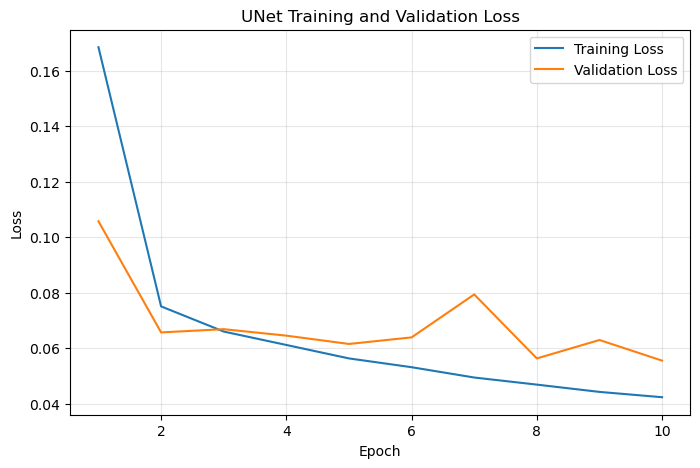

In [33]:
history = np.load(HISTORY_PATH)

train_loss = history["train_loss"]
val_loss = history["val_loss"]
val_dice_history = history["val_dice"]

epochs = np.arange(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("UNet Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Evaluation

Dice score measures the overlap between the predicted and ground-truth
segmentation regions. A Dice score of 1 represents perfect overlap.

The model is evaluated using per-class Dice because good performance is
required for every segmentation label.

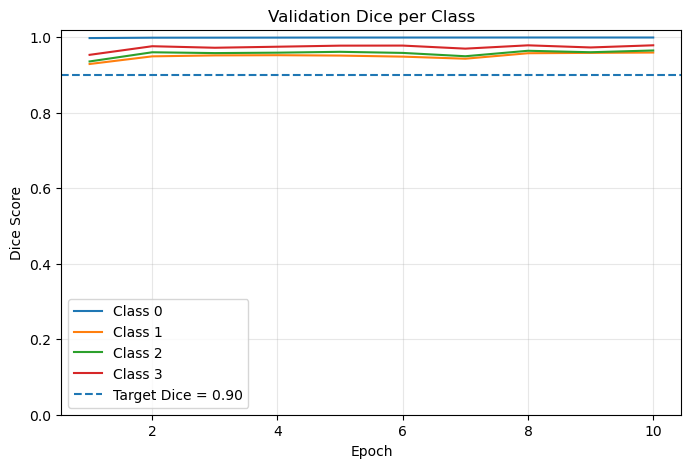

In [34]:
plt.figure(figsize=(8, 5))

for c in range(NUM_CLASSES):
    plt.plot(
        epochs,
        val_dice_history[:, c],
        label=f"Class {c}"
    )

plt.axhline(
    y=0.9,
    linestyle="--",
    label="Target Dice = 0.90"
)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Validation Dice per Class")
plt.ylim(0, 1.02)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [35]:
test_loss, test_dice = validate(
    model,
    test_loader,
    device
)

print(f"Test Loss: {test_loss:.4f}")

for c, score in enumerate(test_dice.tolist()):
    print(f"Class {c} Dice: {score:.4f}")

print(f"Minimum Test Dice: {test_dice.min().item():.4f}")
print(f"Mean Test Dice: {test_dice.mean().item():.4f}")

Test Loss: 0.0554
Class 0 Dice: 0.9993
Class 1 Dice: 0.9630
Class 2 Dice: 0.9645
Class 3 Dice: 0.9788
Minimum Test Dice: 0.9630
Mean Test Dice: 0.9764


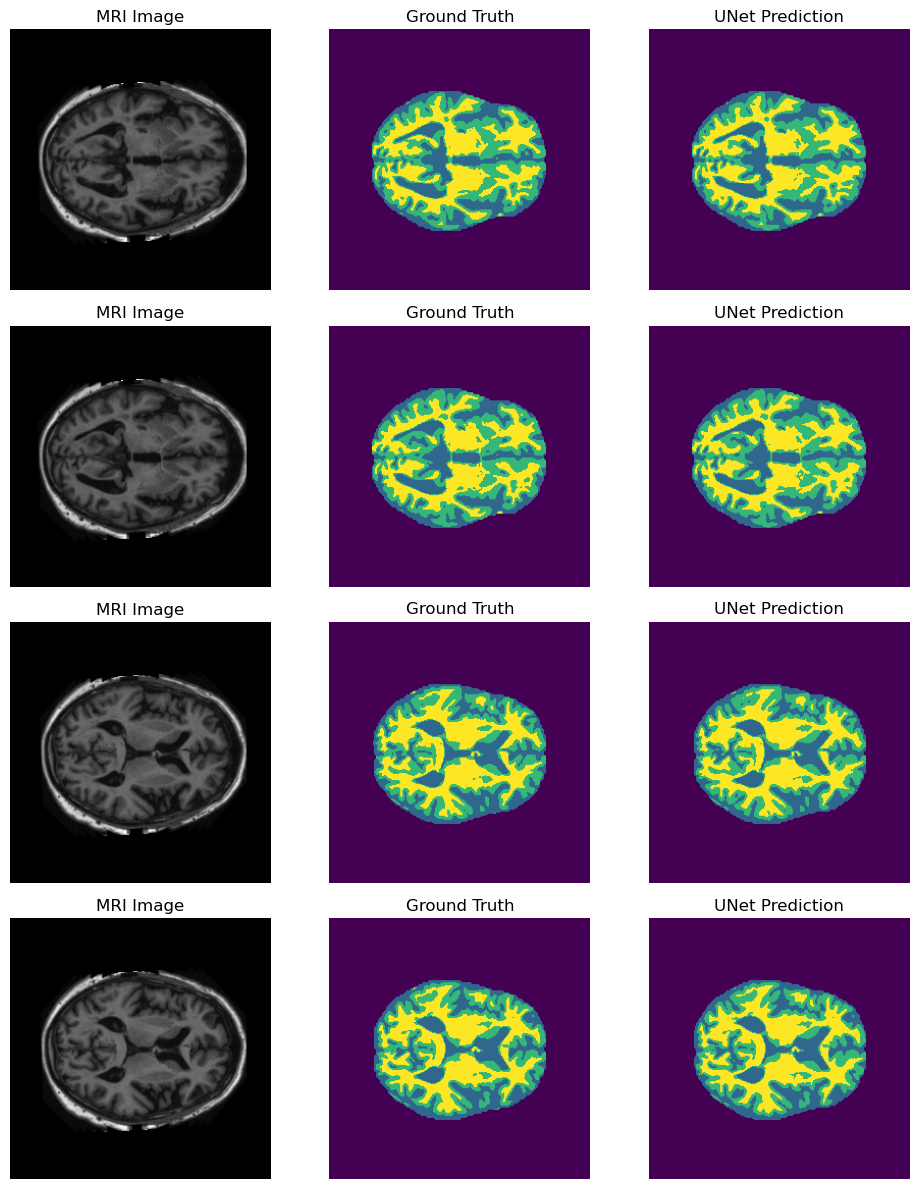

In [36]:
model.eval()

images, masks = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():
    logits = model(images_device)
    predictions = torch.argmax(logits, dim=1).cpu()

num_examples = min(4, images.size(0))

fig, axes = plt.subplots(
    num_examples,
    3,
    figsize=(10, 3 * num_examples)
)

for i in range(num_examples):

    axes[i, 0].imshow(
        images[i].squeeze().numpy(),
        cmap="gray"
    )
    axes[i, 0].set_title("MRI Image")

    axes[i, 1].imshow(
        masks[i].numpy(),
        cmap="viridis",
        vmin=0,
        vmax=NUM_CLASSES - 1
    )
    axes[i, 1].set_title("Ground Truth")

    axes[i, 2].imshow(
        predictions[i].numpy(),
        cmap="viridis",
        vmin=0,
        vmax=NUM_CLASSES - 1
    )
    axes[i, 2].set_title("UNet Prediction")

    for j in range(3):
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

In [37]:
with torch.no_grad():
    logits = model(images_device)

prediction_one_hot = logits_to_one_hot(logits)

print("Logits shape:", logits.shape)
print("Categorical one-hot output shape:", prediction_one_hot.shape)

print(
    "One-hot values:",
    torch.unique(prediction_one_hot).tolist()
)

print(
    "One active class per pixel:",
    torch.all(prediction_one_hot.sum(dim=1) == 1).item()
)

Logits shape: torch.Size([8, 4, 256, 256])
Categorical one-hot output shape: torch.Size([8, 4, 256, 256])
One-hot values: [0.0, 1.0]
One active class per pixel: True


In [38]:
def demo_inference(index=100):
    """
    Run UNet inference on one OASIS test image and visualise the result.
    """
    model.eval()

    # Load one test sample
    image, ground_truth = test_dataset[index]

    # Add batch dimension: [1, 256, 256] -> [1, 1, 256, 256]
    input_image = image.unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        logits = model(input_image)

        # Convert 4-channel logits into categorical prediction
        prediction = torch.argmax(logits, dim=1)

        # Also demonstrate categorical one-hot output
        prediction_one_hot = logits_to_one_hot(logits)

    prediction = prediction.squeeze(0).cpu()

    print(f"Test image index: {index}")
    print("Input shape:", image.shape)
    print("Logits shape:", logits.shape)
    print("One-hot output shape:", prediction_one_hot.shape)
    print("Prediction shape:", prediction.shape)
    print("Predicted classes:", torch.unique(prediction).tolist())
    print(
        "One active class per pixel:",
        bool(torch.all(prediction_one_hot.sum(dim=1) == 1))
    )

    # Visualisation
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(image.squeeze(), cmap="gray")
    axes[0].set_title("Input MRI")

    axes[1].imshow(ground_truth, cmap="viridis", vmin=0, vmax=NUM_CLASSES - 1)
    axes[1].set_title("Ground Truth")

    axes[2].imshow(prediction, cmap="viridis", vmin=0, vmax=NUM_CLASSES - 1)
    axes[2].set_title("UNet Prediction")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Test image index: 100
Input shape: torch.Size([1, 256, 256])
Logits shape: torch.Size([1, 4, 256, 256])
One-hot output shape: torch.Size([1, 4, 256, 256])
Prediction shape: torch.Size([256, 256])
Predicted classes: [0, 1, 2, 3]
One active class per pixel: True


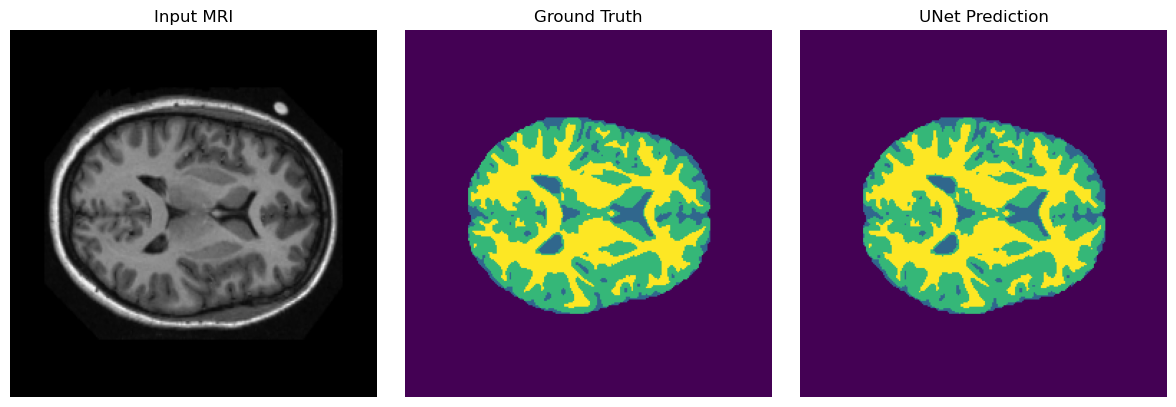

In [39]:
demo_inference(100)